In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
df = pd.read_csv('bodyPerformance.csv')

# Hacemos binario equilibrado

df_A = df[df["class"] == "A"]
df_B = df[df["class"] == "B"]
df_C = df[df["class"] == "C"]
df_D = df[df["class"] == "D"]

n_A = len(df_A)
n_por_clase = n_A // 3

df_B_sample = df_B.sample(n=n_por_clase, random_state=42)
df_C_sample = df_C.sample(n=n_por_clase, random_state=42)
df_D_sample = df_D.sample(n=n_por_clase, random_state=42)

df_0 = pd.concat([df_B_sample, df_C_sample, df_D_sample])

df_A["target"] = 1
df_0["target"] = 0

df_final = pd.concat([df_A, df_0]).sample(frac=1, random_state=42).reset_index(drop=True)

# Ingeniería de variables
df_final['bmi'] = df_final['weight_kg'] / ((df_final['height_cm'] / 100) ** 2)
df_final['relative_grip'] = df_final['gripForce'] / df_final['weight_kg']

df_final['gender'] = df_final['gender'].map({'M': 1, 'F': 0})

# Dividimos entre datos y objetivo
y = df_final['target']
X = df_final.drop(columns=['class', 'target'], axis=1)

C:\Users\miguelmr\AppData\Local\Temp\ipykernel_20184\2593056450.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_A["target"] = 1


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Modelamos el Random Forest con Grid Search
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=3, 
    n_jobs=-1, 
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 81 candidates, totalling 243 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 


Mejor precisión del Random Forest: 0.8993
              precision    recall  f1-score   support

    No Élite       0.94      0.86      0.89       671
       Élite       0.87      0.94      0.90       669

    accuracy                           0.90      1340
   macro avg       0.90      0.90      0.90      1340
weighted avg       0.90      0.90      0.90      1340



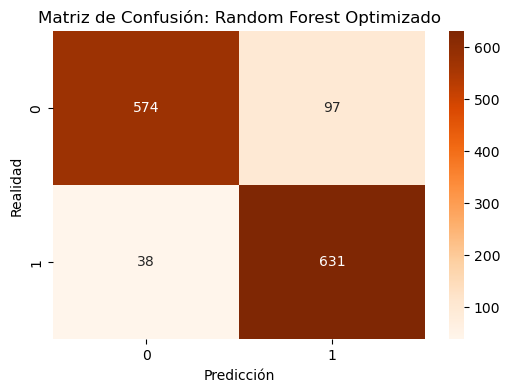

In [4]:
mejor_rf = grid_search.best_estimator_

# Comprobamos calidad del modelo
y_pred_rf = mejor_rf.predict(X_test)
final_acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nMejor precisión del Random Forest: {final_acc_rf:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['No Élite', 'Élite']))

# Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges')
plt.title("Matriz de Confusión: Random Forest Optimizado")
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.show()

C:\Users\miguelmr\AppData\Local\Temp\ipykernel_20184\3231287170.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


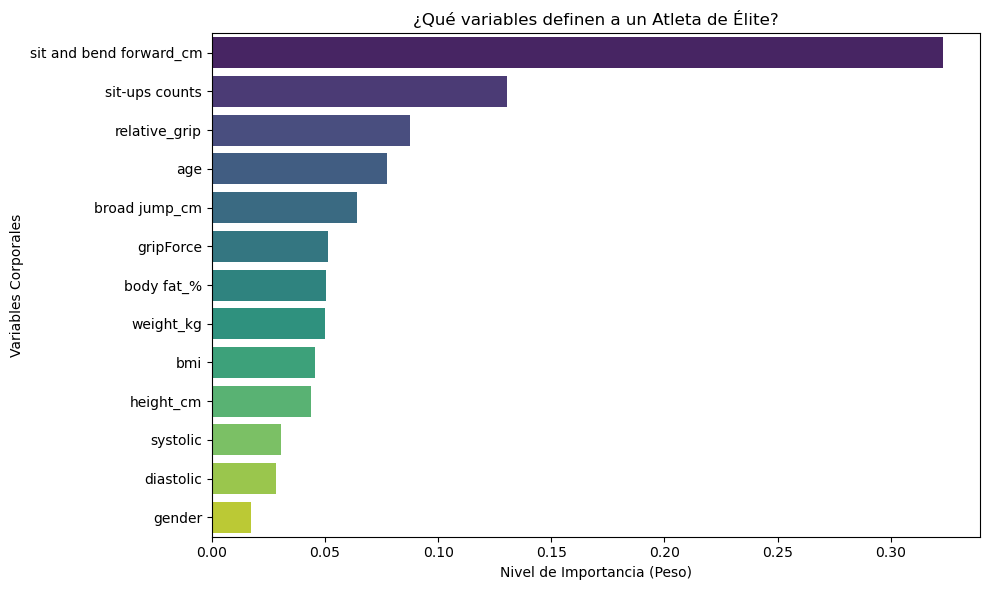

In [5]:
importancias = mejor_rf.feature_importances_
nombres_columnas = X.columns

# Ordenamos de mayor a menor
tabla_importancias = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)


# Dibujamos el gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=tabla_importancias, 
    palette='viridis'
)
plt.title("¿Qué variables definen a un Atleta de Élite?")
plt.xlabel("Nivel de Importancia (Peso)")
plt.ylabel("Variables Corporales")
plt.tight_layout()
plt.show()